In [1]:
from datetime import datetime, timedelta
from finpie.datasource.service import DataService
from mt5_backtest_runner import run_mt5_backtest
import glob
import os
import pandas as pd
from functools import reduce
import re
import math
from finpie.data.timeseries import TimeSeries
from finpie.data.multitimeseries import MultiTimeSeries
from finpie.data.spreadtimeseries import SpreadTimeSeries
from finpie.data.ratiotimeseries import RatioTimeSeries
import numpy as np
import matplotlib.pyplot as plt
from finpie.analytics.genetic_portfolio_optimizer import GeneticPortfolioOptimizer, OptimizationConfig

Using GPU: NVIDIA GeForce RTX 3090
GPU Memory: 25.8 GB


In [2]:
data_path = r"C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\backtests"
prod_path = r"C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\prod"

In [3]:
df = pd.read_parquet('data/mts2.parquet')

In [4]:
mts = MultiTimeSeries.read_parquet('data/mts2.parquet')
mts_is, mts_os = mts.slice(0.5)

In [5]:
search_space = [
    #{
    #    'name': '10 strategies with 100% weight',
    #    'max_strategies': 10,
    #},
    #{
    #    'name': '20 strategies with 100% weight',
    #    'max_strategies': 20,
    #},
    #{
    #    'name': '10 strategies with max ratio 5',
    #    'max_strategies': 10,
    #    'max_ratio': 5
    #},
    {
        'name': '20 strategies with max ratio 5',
        'max_strategies': 20,
        'max_ratio': 5
    }
]

In [6]:
risk_reward = abs(mts.diff().max() / mts.diff().min())

In [7]:
def custom_fitness_score(self, timeseries: TimeSeries) -> float:
        return timeseries.value(-1)[0] / timeseries.volatility(method = 'absolute', annualized = True)[0]

In [8]:
def custom_fitness_score(self, timeseries: TimeSeries) -> float:
        return timeseries.value(-1)[0] * (-15_000 / timeseries.max_drawdown(percentage = False, method='absolute')[0])

In [9]:
def custom_fitness_score(self, timeseries: TimeSeries) -> float:
        return timeseries.iloc[-1][timeseries.columns[0]]

In [10]:
for search_config in search_space:
    search_config['config'] = OptimizationConfig(
    weight_mode="binary",
    population_size=500,           # Number of individuals in population
    max_generations=1000,          # Maximum number of generations  
    max_strategies=search_config['max_strategies'],             # Maximum strategies per portfolio
    elite_size=10,                 # Number of best individuals to preserve
    tournament_size=5,             # Tournament selection size
    crossover_rate=0.8,           # Probability of crossover
    mutation_rate=0.1,            # Probability of mutation
    early_stopping_patience=100,   # Stop if no improvement for N generations
    convergence_threshold=1e-6,   # Minimum improvement threshold
    fitness_score_function=custom_fitness_score,
    random_seed=np.random.randint(1, 1000000), # For reproducible results
    mass_extinction_events=20,     # Number of extinction events to trigger
    extinction_percentage=0.5,     # Percentage of population to kill (0.0 to 1.0)
    protect_elite_from_extinction=True  # Whether elite individuals are protected from extinction
    )
    if 'max_ratio' in search_config:
        mapping = (risk_reward <= search_config['max_ratio']) & (risk_reward >= 1/search_config['max_ratio'])
        search_config['ts_is'] = MultiTimeSeries(mts_is[mapping[mapping == True].index].copy())
        search_config['ts_os'] = MultiTimeSeries(mts_os[mapping[mapping == True].index].copy())
    else:
        search_config['ts_is'] = mts_is
        search_config['ts_os'] = mts_os

In [ ]:
for search_config in search_space:
    optimizer = GeneticPortfolioOptimizer(search_config['ts_is'], search_config['config'])
    best_individual, history = optimizer.optimize()
    search_config['best_individual'] = best_individual
    search_config['history'] = history

Starting genetic optimization...
Population size: 500
Max generations: 1000
Available strategies: 18054
Generation 0: Best fitness: 723235.00, Avg fitness: 346798.64, Best PnL: 723235.00, Best strategies: 20
Generation 1: Best fitness: 801493.00, Avg fitness: 592272.31, Best PnL: 801493.00, Best strategies: 20
Generation 2: Best fitness: 831140.00, Avg fitness: 677773.88, Best PnL: 831140.00, Best strategies: 20
Generation 3: Best fitness: 837639.00, Avg fitness: 720196.35, Best PnL: 837639.00, Best strategies: 20
Generation 4: Best fitness: 866033.00, Avg fitness: 739181.66, Best PnL: 866033.00, Best strategies: 20
Generation 5: Best fitness: 889800.00, Avg fitness: 757746.36, Best PnL: 889800.00, Best strategies: 20
Generation 6: Best fitness: 904666.00, Avg fitness: 775818.24, Best PnL: 904666.00, Best strategies: 20
Generation 7: Best fitness: 916757.00, Avg fitness: 792125.08, Best PnL: 916757.00, Best strategies: 20
Generation 8: Best fitness: 916757.00, Avg fitness: 810073.49, B

In [50]:
for search_config in search_space:
    search_config['portfolio_ts_is'] = search_config['ts_is'].portfolio(weights = search_config['best_individual'].get_weights(), shares = True, percentage = False)
    search_config['portfolio_ts_os'] = search_config['ts_os'].portfolio(weights = search_config['best_individual'].get_weights(), shares = True, percentage = False)

In [21]:
best_is_pnl = mts_is.value(-1).sort_values(ascending = False)[:20].index

<Axes: xlabel='Date'>

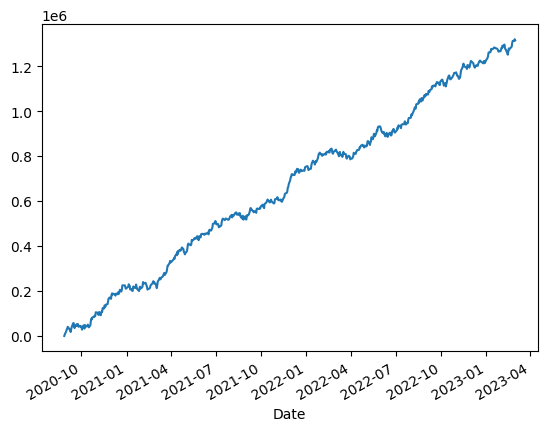

In [28]:
mts_is.data[best_is_pnl].diff().sum(axis = 1).cumsum().plot()

<Axes: xlabel='Date'>

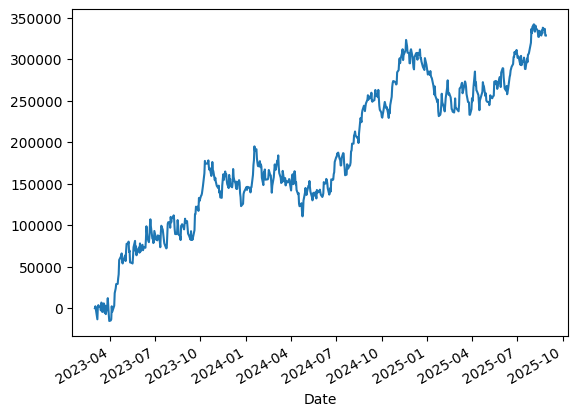

In [27]:
mts_os.data[best_is_pnl].diff().sum(axis = 1).cumsum().plot()

In [ ]:
weights = {
    "WIN$N_WSP$N_RSI_RSI_RATIO_8431441702667994264": 1,
"WIN$N_WSP$N_RSI_RSI_RATIO_7066963457615126378": 1,
"WIN$N_WSP$N_MOMENTUM_MOMENTUM_RATIO_15745913838704788129": 1,
"WIN$N_WIN$N_RSI_RETURNS_RATIO_2147226274691018798": 1,
"WIN$N_WIN$N_RETURNS_PRICE_MAMA_DISTANCE_SPREAD_15541506442948395777": 1,
"WIN$N_WIN$N_RETURNS_MAMA_DISTANCE_SPREAD_13287722170295900052": 1,
"WIN$N_WIN$N_PRICES_RSI_RATIO_11616511845534960856": 1,
"WIN$N_WIN$N_MOMENTUM_RETURNS_RATIO_4941167865114217978": 1,
"WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_3715281047835224916": 1,
"WIN$N_WIN$N_MOMENTUM_PRICE_MAMA_DISTANCE_SPREAD_11721238061880443942": 1,
"WIN$N_WIN$N_MOMENTUM_MAMA_DISTANCE_SPREAD_16975149508379497472": 1,
"WIN$N_WIN$N_MOMENTUM_MAMA_DISTANCE_SPREAD_4503286728177737452": 1,
"WIN$N_WDO$N_RSI_RSI_RATIO_14399917438557488223": 1,
"WIN$N_WDO$N_RSI_RSI_RATIO_12548509201202940488": 1,
"WIN$N_WDO$N_PRICES_PRICES_RATIO_18112357166312811078": 1,
"WIN$N_WDO$N_PRICE_MAMA_DISTANCE_PRICE_MAMA_DISTANCE_SPREAD_15652472584227467281": 1,
"WIN$N_WDO$N_MOMENTUM_MOMENTUM_RATIO_545334067150811836": 1,
"WIN$N_WDO$N_MAMA_DISTANCE_MAMA_DISTANCE_SPREAD_1415433955947169891": 1,
"WIN$N_BOVA11_RETURNS_RETURNS_SPREAD_13958889995319245783": 1,
"WIN$N_BOVA11_MAMA_DISTANCE_MAMA_DISTANCE_SPREAD_10363284119758261605": 1,}

In [19]:
t = mts.portfolio(weights=weights, percentage = False, shares = True) * 2

array([[<Axes: title={'center': 'portfolio'}>]], dtype=object)

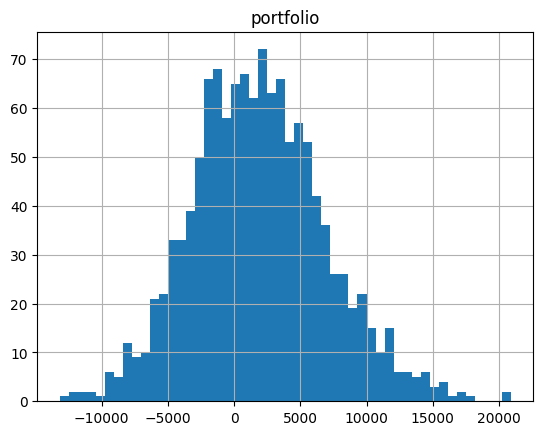

In [24]:
t.returns(method='absolute').data.hist(bins=50)

In [59]:
for key in search_space[3]['best_individual'].get_weights().keys():
    import shutil
    import os

    # Get the source and destination paths
    source_path = os.path.join(data_path, '..', 'parameters', f'{key}.set')
    dest_path = os.path.join(data_path, '..', 'prod')

    # Create destination directory if it doesn't exist
    os.makedirs(dest_path, exist_ok=True)

    # Copy the file
    try:
        shutil.copy2(source_path, dest_path)
        print(f"✅ Copied {key}.set to prod directory")
    except FileNotFoundError:
        print(f"❌ File {key}.set not found in parameters directory")
    except Exception as e:
        print(f"❌ Error copying {key}.set: {e}")

✅ Copied WIN$N_BOVA11_MAMA_DISTANCE_MAMA_DISTANCE_SPREAD_10363284119758261605.set to prod directory
✅ Copied WIN$N_BOVA11_RETURNS_RETURNS_SPREAD_13958889995319245783.set to prod directory
✅ Copied WIN$N_WDO$N_MAMA_DISTANCE_MAMA_DISTANCE_SPREAD_1415433955947169891.set to prod directory
✅ Copied WIN$N_WDO$N_MOMENTUM_MOMENTUM_RATIO_545334067150811836.set to prod directory
✅ Copied WIN$N_WDO$N_PRICES_PRICES_RATIO_18112357166312811078.set to prod directory
✅ Copied WIN$N_WDO$N_PRICE_MAMA_DISTANCE_PRICE_MAMA_DISTANCE_SPREAD_15652472584227467281.set to prod directory
✅ Copied WIN$N_WDO$N_RSI_RSI_RATIO_12548509201202940488.set to prod directory
✅ Copied WIN$N_WDO$N_RSI_RSI_RATIO_14399917438557488223.set to prod directory
✅ Copied WIN$N_WIN$N_MOMENTUM_MAMA_DISTANCE_SPREAD_16975149508379497472.set to prod directory
✅ Copied WIN$N_WIN$N_MOMENTUM_MAMA_DISTANCE_SPREAD_4503286728177737452.set to prod directory
✅ Copied WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_3715281047835224916.set to prod directory
✅ Co

In [ ]:
(best_strategy.data * 2)

,portfolio
Date,
2020-08-27,-102.0
2020-08-28,1536.0
2020-08-31,1530.0
2020-09-01,17216.0
2020-09-02,26188.0
...,...
2025-08-22,2326206.0
2025-08-25,2325650.0
2025-08-26,2329900.0
